# Final Project Amazon Reviews
### 12/12/2025
### Aren Mizuno
### Big Data and Cloud Computing 31013 IP03
#### Part 3

In [1]:
# Imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window
from pyspark.sql.functions import col, split, monotonically_increasing_id
from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    CountVectorizer,
    IDF,
    HashingTF,
    MinHashLSH
)
from pyspark.ml.functions import vector_to_array
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
# Paths
reviews_path = "gs://msca-bdp-data-open/final_project_reviews/reviews_parquet"
meta_path = "gs://msca-bdp-data-open/final_project_reviews/meta_parquet"
output_path = "gs://msca-bdp-students-bucket/shared_data/amizuno/amazon"

In [3]:
# Load data
df_reviews = spark.read.parquet(reviews_path)
df_meta = spark.read.parquet(meta_path)

In [4]:
# Drop rows where null for average_rating, main_category, parent_asin, price, rating_number
# Columns required to be non-null
required_cols = ["average_rating", "main_category", "parent_asin", "price", "rating_number"]

# Count before dropping
before = df_meta.count()

# Drop rows with NULL in any required column
df_meta = df_meta.dropna(subset=required_cols)

# Count after dropping
after = df_meta.count()

# Rows removed
dropped = before - after

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Rows dropped: {dropped}")

Rows before: 4320533
Rows after:  1716241
Rows dropped: 2604292


In [5]:
# Drop duplicates
df_reviews = df_reviews.dropDuplicates()

In [6]:
# Clean df_reviews
# Step 1 -- Convert
len_udf = F.udf(lambda s: 0 if not s else len(s), T.IntegerType())
df_reviews_conv = (
    df_reviews
    # Convert timestamp 
    .withColumn("review_date",
        F.to_date(
            F.from_unixtime((F.col("timestamp") / 1000).cast("long"))
        )
    )
)

# Step 2 -- Filter
df_reviews_filter = (
    df_reviews_conv
    # valid product
    .filter("asin IS NOT NULL AND parent_asin IS NOT NULL")
    
    # valid helpful vote
    .filter("helpful_vote >= 0")

    # valid rating range
    .filter("rating >= 1.0 AND rating <= 5.0")
    
    # valid date
    .filter("review_date IS NOT NULL")
    .filter(F.col("review_date") <= F.current_date())
    
    # valid user
    .filter("user_id IS NOT NULL")
        
    # valid verified purchase
    .filter("verified_purchase IS NOT NULL")
)

df_reviews_filter = df_reviews_filter.drop("asin", "helpful_vote", "timestamp", "verified_purchase")

In [7]:
# Clean df_meta
# Step 1 -- Convert into string
df_meta_conv = (
    df_meta
    # Clean string field
    .withColumn("main_category", F.regexp_replace(F.col("main_category").cast("string"), r"\s+", " "))
    
    # Convert price into int
    .withColumn("price", F.regexp_extract(F.col("price"), r"[\d\.]+", 0).cast("double"))
)

# Step 2 -- Filter
df_meta_filter = (
    df_meta_conv
    # valid avg rating
    .filter("average_rating >= 1.0 AND average_rating <= 5.0")
    
    # valid category
    .filter("main_category IS NOT NULL")
    
    # valid product
    .filter("parent_asin IS NOT NULL")
    
    # valid price
    .filter("price > 0")
    
    # valid rating_number
    .filter("rating_number >= 1")
)

df_meta_filter = df_meta_filter.drop("author", "bought_together", "categories", "description", "store", "subtitle", "title", "rating_number")

- Compare the effectiveness of similarity-based detection (e.g., SimHash, MinHash, LSH) on recent reviews (e.g., 2022–2023) versus older reviews (pre-2022)
    - Are similarity detection techniques less effective on recent data due to more advanced or diversified AI-generated reviews?

In [8]:
df_reviews_time = df_reviews_filter.select("review_date", "text", "title")

df_recent = df_reviews_time.filter(F.col("review_date") >= "2022-01-01")
df_old = df_reviews_time.filter(F.col("review_date") <  "2022-01-01")
df_recent = df_recent.sample(withReplacement=False, fraction=0.001, seed=42)
df_old = df_old.sample(withReplacement=False, fraction=0.001, seed=42)

print("Recent count:", df_recent.count())
print("Old count:", df_old.count())

Recent count: 12411


Old count: 51498


In [9]:
def compute_dup_percent(df, column_name, id_prefix):

    # 1. CLEAN + TOKENIZE
    df_clean = df.select(column_name).withColumn(
        "clean",
        F.regexp_replace(column_name, r"[\p{P}\p{C}]", "")
    )

    df_clean = df_clean.withColumn("raw_words", split("clean", " "))
    df_clean = df_clean.withColumn(
        "clean_words",
        F.expr("filter(raw_words, w -> length(w) >= 3)")
    )

    remover = StopWordsRemover(inputCol="clean_words", outputCol="filtered_words")
    df_clean = remover.transform(df_clean)

    # Unique ID (stable)
    df_clean = df_clean.withColumn(
        "uid",
        F.concat(F.lit(id_prefix + "_"), monotonically_increasing_id())
    )

    df_clean = df_clean.select("uid", column_name, "filtered_words")
    df_clean = df_clean.filter(F.size("filtered_words") > 0)

    # 2. CountVectorizer
    vec = CountVectorizer(inputCol="filtered_words", outputCol="features", minDF=1.0)
    vec_model = vec.fit(df_clean)
    df_vec = vec_model.transform(df_clean)
    df_vec = df_vec.withColumn("arr", vector_to_array("features"))
    df_vec = df_vec.filter(F.expr("array_max(arr) > 0"))

    total = df_vec.count()

    # 3. MinHash
    mh = MinHashLSH(inputCol="features", outputCol="hashes", numHashTables=5)
    mh_model = mh.fit(df_vec)
    df_hashed = mh_model.transform(df_vec)

    # 4. Duplicate counts
    def dup_count(th):
        dups = (
            mh_model.approxSimilarityJoin(df_hashed, df_hashed, th)
            .filter("datasetA.uid < datasetB.uid")
            .select("datasetA.uid")
            .distinct()
            .count()
        )
        return dups

    dup_03 = dup_count(0.3)
    dup_05 = dup_count(0.5)
    dup_07 = dup_count(0.7)

    return {
        "total": total,
        "dup_0.3": dup_03,
        "dup_0.5": dup_05,
        "dup_0.7": dup_07
    }

In [10]:
# TITLE duplicate %, old & recent
title_old = compute_dup_percent(df_old,  "title", "old_title")    
title_recent = compute_dup_percent(df_recent, "title", "rec_title") 

25/12/08 20:58:53 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 20:59:48 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 21:00:36 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 21:02:10 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 21:02:33 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 21:02:57 INFO PlanChangeLogger:                                   

In [11]:
# TEXT duplicate %, old & recent
text_old = compute_dup_percent(df_old,  "text", "old_text")
text_recent = compute_dup_percent(df_recent, "text", "rec_text")

25/12/08 21:04:33 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 21:05:38 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 21:06:51 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 21:08:15 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 21:08:34 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 21:08:52 INFO PlanChangeLogger:                                   

In [12]:
def extract_dup_arrays(old, recent):
    thresholds = ["0.3", "0.5", "0.7"]

    old_dup = [
        100 * old["dup_0.3"] / old["total"],
        100 * old["dup_0.5"] / old["total"],
        100 * old["dup_0.7"] / old["total"],
    ]

    recent_dup = [
        100 * recent["dup_0.3"] / recent["total"],
        100 * recent["dup_0.5"] / recent["total"],
        100 * recent["dup_0.7"] / recent["total"],
    ]

    old_unique = [100 - x for x in old_dup]
    recent_unique = [100 - x for x in recent_dup]

    return thresholds, old_dup, recent_dup, old_unique, recent_unique

In [13]:
def plot_dup_chart(thresholds, old_dup, recent_dup, old_unique, recent_unique, title_suffix):

    x = np.arange(len(thresholds))
    width = 0.35

    plt.figure(figsize=(12,6))

    # OLD STACK
    plt.bar(x - width/2, old_unique, width, label="Old Unique %", color="#FFD39B")
    plt.bar(x - width/2, old_dup,    width, bottom=old_unique, label="Old Duplicate %", color="#FF7F50")

    # RECENT STACK
    plt.bar(x + width/2, recent_unique, width, label="Recent Unique %", color="#A6CEE3")
    plt.bar(x + width/2, recent_dup,    width, bottom=recent_unique, label="Recent Duplicate %", color="#1F78B4")

    plt.xticks(x, thresholds)
    plt.xlabel("Jaccard Threshold")
    plt.ylabel("Percent (%)")
    plt.title(f"Duplicate % in OLD vs RECENT Reviews ({title_suffix})")
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

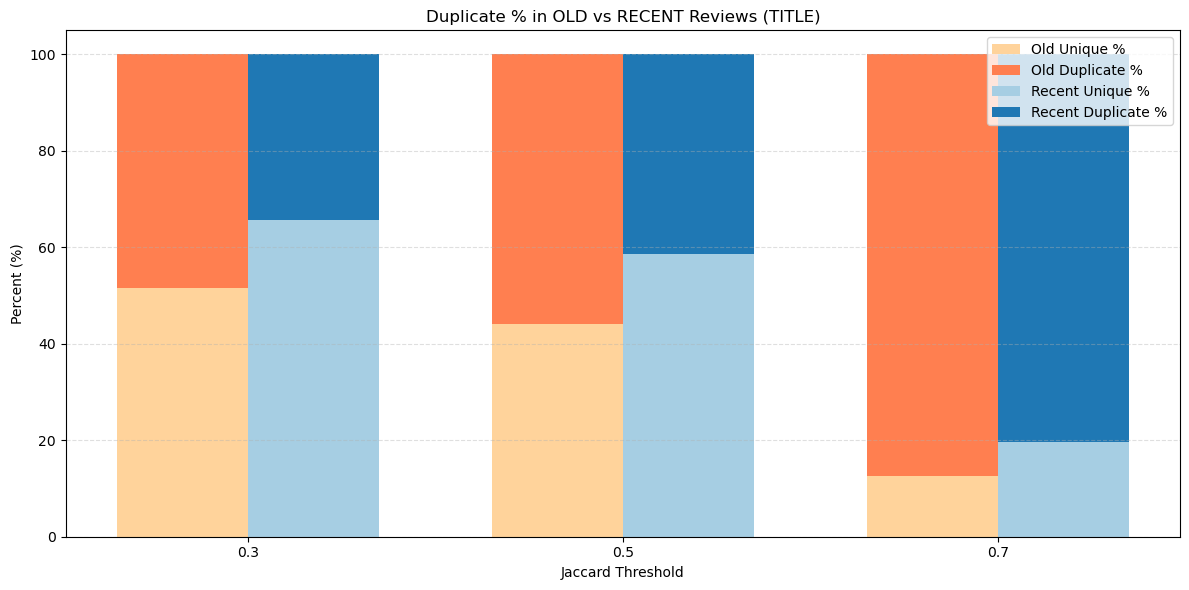

In [14]:
thr, o_d, r_d, o_u, r_u = extract_dup_arrays(title_old, title_recent)
plot_dup_chart(thr, o_d, r_d, o_u, r_u, "TITLE")

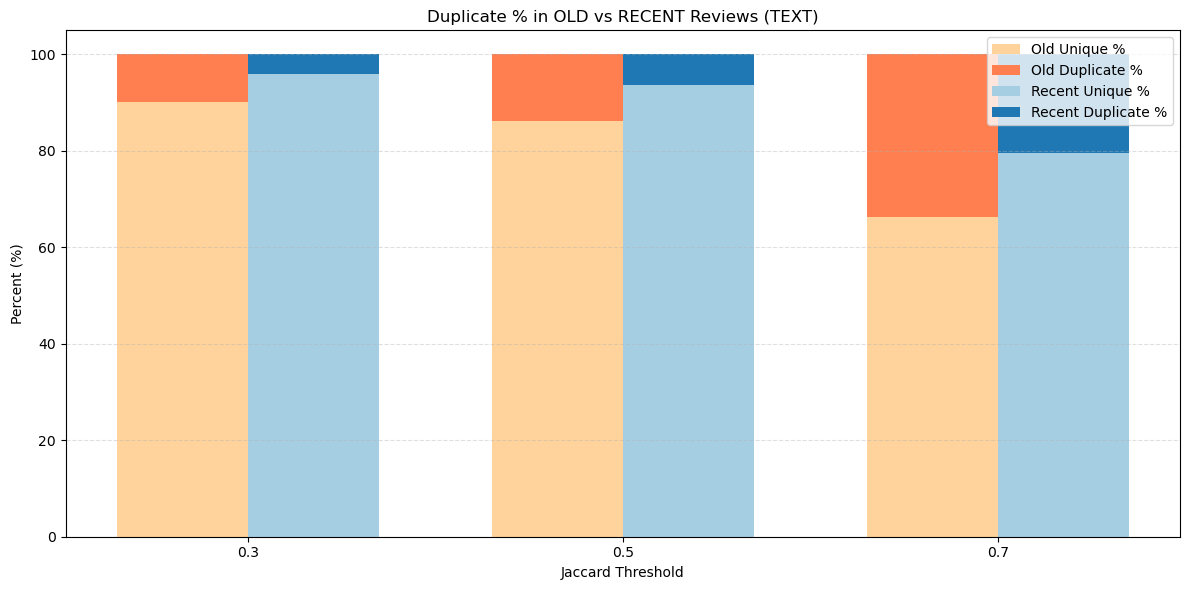

In [15]:
thr, o_d, r_d, o_u, r_u = extract_dup_arrays(text_old, text_recent)
plot_dup_chart(thr, o_d, r_d, o_u, r_u, "TEXT")